# Final Model Evaluation, Visualisation and Conclusions


It includes:
- loading the final feature dataset
- rebuilding the temporal train/test split
- training the final tuned Gradient Boosted Tree model
- comparing final model performance with all baseline models
- visualising predictions, residuals, and feature importance
- writing final conclusions for the notebook

In [0]:
# Databricks notebook source
df = spark.table("default.traffic_features_final")

print("Table loaded successfully")
print("Rows:", df.count())
print("Columns:", len(df.columns))
display(df.limit(5))

Table loaded successfully
Rows: 7503913
Columns: 20


avg_speed,max_speed,min_speed,speed_std,avg_length,max_length,length_std,avg_headway,min_headway,avg_gap,min_gap,month,day,hour,cosit,lane,day_type_index,speed_category_index,congestion_index_index,vehicle_count
90.55652173913043,122.0,66.0,12.220339174914987,4.515652173913043,5.6,0.33991518662176584,28.772,0.0,28.578347826086958,0.0,1,1,1,1505,8,0.0,0.0,2.0,115
82.73045822102426,114.0,41.0,9.784025289754064,4.487061994609166,14.3,0.9873222009955585,8.471994609164419,0.0,8.385067385444742,0.0,1,1,12,202104,1,0.0,3.0,3.0,371
103.99004424778761,139.0,72.0,10.678058894188743,4.529756637168141,11.4,0.5311655276703832,4.007024336283187,0.0,3.7729977876106213,0.0,1,1,13,15012,4,0.0,2.0,1.0,904
74.54838709677419,94.0,54.0,9.875352178285151,4.461290322580646,5.5,0.41042857223057205,22.575161290322583,0.0,22.485806451612905,0.0,1,1,14,31021,2,0.0,3.0,2.0,31
99.6984126984127,137.0,72.0,12.47272497923281,4.671428571428572,17.1,1.6622398968423233,44.668253968253964,0.0,44.503650793650785,0.0,1,1,10,1243,1,0.0,2.0,0.0,63


##  Feature Readiness Check

This step checks:
- missing values
- feature data types
- basic value ranges


In [0]:

from pyspark.sql.functions import col

final_features = [
    "avgspeed", "maxspeed", "minspeed", "speedstd",
    "avglength", "maxlength", "lengthstd",
    "avgheadway", "minheadway",
    "avggap", "mingap",
    "month", "day", "hour",
    "cosit", "lane",
    "daytypeindex", "speedcategoryindex", "congestionindexindex"
]

target = "vehiclecount"

print("Number of input features:", len(final_features))
print("Target column:", target)
print("All selected columns:", final_features + [target])

Number of input features: 19
Target column: vehiclecount
All selected columns: ['avgspeed', 'maxspeed', 'minspeed', 'speedstd', 'avglength', 'maxlength', 'lengthstd', 'avgheadway', 'minheadway', 'avggap', 'mingap', 'month', 'day', 'hour', 'cosit', 'lane', 'daytypeindex', 'speedcategoryindex', 'congestionindexindex', 'vehiclecount']


In [0]:
df.columns

['avg_speed',
 'max_speed',
 'min_speed',
 'speed_std',
 'avg_length',
 'max_length',
 'length_std',
 'avg_headway',
 'min_headway',
 'avg_gap',
 'min_gap',
 'month',
 'day',
 'hour',
 'cosit',
 'lane',
 'day_type_index',
 'speed_category_index',
 'congestion_index_index',
 'vehicle_count']

In [0]:

from pyspark.ml.feature import VectorAssembler

final_features = [
    "avg_speed", "max_speed", "min_speed", "speed_std",
    "avg_length", "max_length", "length_std",
    "avg_headway", "min_headway",
    "avg_gap", "min_gap",
    "month", "day", "hour",
    "cosit", "lane",
    "day_type_index", "speed_category_index", "congestion_index_index"
]

target = "vehicle_count"

assembler = VectorAssembler(
    inputCols=final_features,
    outputCol="features"
)

df_assembled = assembler.transform(df).select("features", target, "month")

print("Feature vector assembled successfully")
print("Rows:", df_assembled.count())
display(df_assembled.limit(5))

Feature vector assembled successfully
Rows: 7503913


features,vehicle_count,month
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""104.50184501845018"",""168.0"",""69.0"",""11.113886848351916"",""4.547785977859778"",""16.4"",""0.9844937740170997"",""6.5493726937269425"",""0.0"",""6.38745387453874"",""0.0"",""1.0"",""1.0"",""21.0"",""1502.0"",""6.0"",""0.0"",""2.0"",""1.0""]}",542,1
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""123.88888888888889"",""168.0"",""103.0"",""14.879472195291655"",""4.527777777777778"",""5.8"",""0.5131283012997541"",""63.733333333333334"",""0.0"",""63.64444444444444"",""0.0"",""1.0"",""1.0"",""3.0"",""15010.0"",""2.0"",""0.0"",""1.0"",""0.0""]}",18,1
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""82.21875"",""119.0"",""53.0"",""11.729042437809513"",""4.412499999999999"",""5.2"",""0.27917110870666406"",""46.42296875"",""0.0"",""46.21484375"",""0.0"",""1.0"",""1.0"",""10.0"",""1812.0"",""2.0"",""0.0"",""3.0"",""0.0""]}",64,1
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""97.31724137931035"",""130.0"",""67.0"",""12.98861865478339"",""4.903448275862067"",""19.2"",""1.9335277845137344"",""22.209793103448273"",""0.0"",""22.024482758620692"",""0.0"",""1.0"",""1.0"",""6.0"",""1044.0"",""6.0"",""0.0"",""2.0"",""2.0""]}",145,1
"{""type"":""1"",""size"":null,""indices"":null,""values"":[""83.11258278145695"",""120.0"",""50.0"",""10.97909713735309"",""4.399337748344371"",""12.9"",""0.9408858725507376"",""20.105960264900666"",""0.0"",""19.837218543046358"",""0.0"",""1.0"",""1.0"",""14.0"",""20023.0"",""1.0"",""0.0"",""3.0"",""2.0""]}",151,1


## Temporal Train-Test Split

To avoid data leakage, the dataset is split chronologically.

- Training set: months 1 to 9
- Test set: months 10 to 12



In [0]:
from pyspark.sql.functions import col, avg, abs as spark_abs
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [0]:
# Databricks notebook source
from pyspark.sql.functions import col

train_df = df_assembled.filter(col("month") <= 9)
test_df = df_assembled.filter(col("month") > 9)

train_count = train_df.count()
test_count = test_df.count()
total_count = df_assembled.count()

print("Temporal Train-Test Split")
print("-" * 40)
print("Training rows (Jan-Sep):", train_count)
print("Test rows (Oct-Dec):", test_count)
print("Train ratio: {:.1f}%".format(train_count / total_count * 100))
print("Test ratio: {:.1f}%".format(test_count / total_count * 100))

Temporal Train-Test Split
----------------------------------------
Training rows (Jan-Sep): 5955667
Test rows (Oct-Dec): 1548246
Train ratio: 79.4%
Test ratio: 20.6%


##  Final Tuned Gradient Boosted Tree Model

The final model is a tuned Gradient Boosted Tree regressor.

It is selected because it performed best during model comparison and hyperparameter optimisation.

In [0]:
# Databricks notebook source
from pyspark.ml.regression import GBTRegressor

final_gbt = GBTRegressor(
    featuresCol="features",
    labelCol="vehicle_count",
    maxDepth=10,
    maxIter=50,
    stepSize=0.1,
    seed=42
)

print("Training final tuned Gradient Boosted Tree model...")
final_gbt_model = final_gbt.fit(train_df)
print("Training complete.")

Training final tuned Gradient Boosted Tree model...
Training complete.


##  Final Model Predictions and Evaluation

The trained tuned Gradient Boosted Tree model is now applied to the held-out test set.

We evaluate it using:
- RMSE,
- MAE,
- R².

These metrics show how well the final model generalises to future traffic data.

In [0]:
# Databricks notebook source
from pyspark.ml.evaluation import RegressionEvaluator

final_predictions = final_gbt_model.transform(test_df)

evaluator_rmse = RegressionEvaluator(
    labelCol="vehicle_count",
    predictionCol="prediction",
    metricName="rmse"
)

evaluator_mae = RegressionEvaluator(
    labelCol="vehicle_count",
    predictionCol="prediction",
    metricName="mae"
)

evaluator_r2 = RegressionEvaluator(
    labelCol="vehicle_count",
    predictionCol="prediction",
    metricName="r2"
)

final_rmse = evaluator_rmse.evaluate(final_predictions)
final_mae = evaluator_mae.evaluate(final_predictions)
final_r2 = evaluator_r2.evaluate(final_predictions)

print("Final Tuned GBT Evaluation Metrics")
print("-" * 45)
print("RMSE:", round(final_rmse, 4))
print("MAE :", round(final_mae, 4))
print("R²  :", round(final_r2, 4))

display(final_predictions.select("vehicle_count", "prediction").limit(10))

Final Tuned GBT Evaluation Metrics
---------------------------------------------
RMSE: 28.49
MAE : 14.5085
R²  : 0.9936


vehicle_count,prediction
75,84.66694228440456
2,9.387845526516118
858,886.9940889099132
806,798.8772361843078
494,500.1238459371926
534,545.0974582860463
657,645.6684244379467
418,407.70739466687894
34,38.342011795216635
11,24.536411865905784


## Prediction and Residual Visualisations

To better understand the final model, we compare actual and predicted values and inspect residuals.

These plots help assess:
- overall fit,
- error spread,
- whether the model is biased at higher or lower traffic volumes.

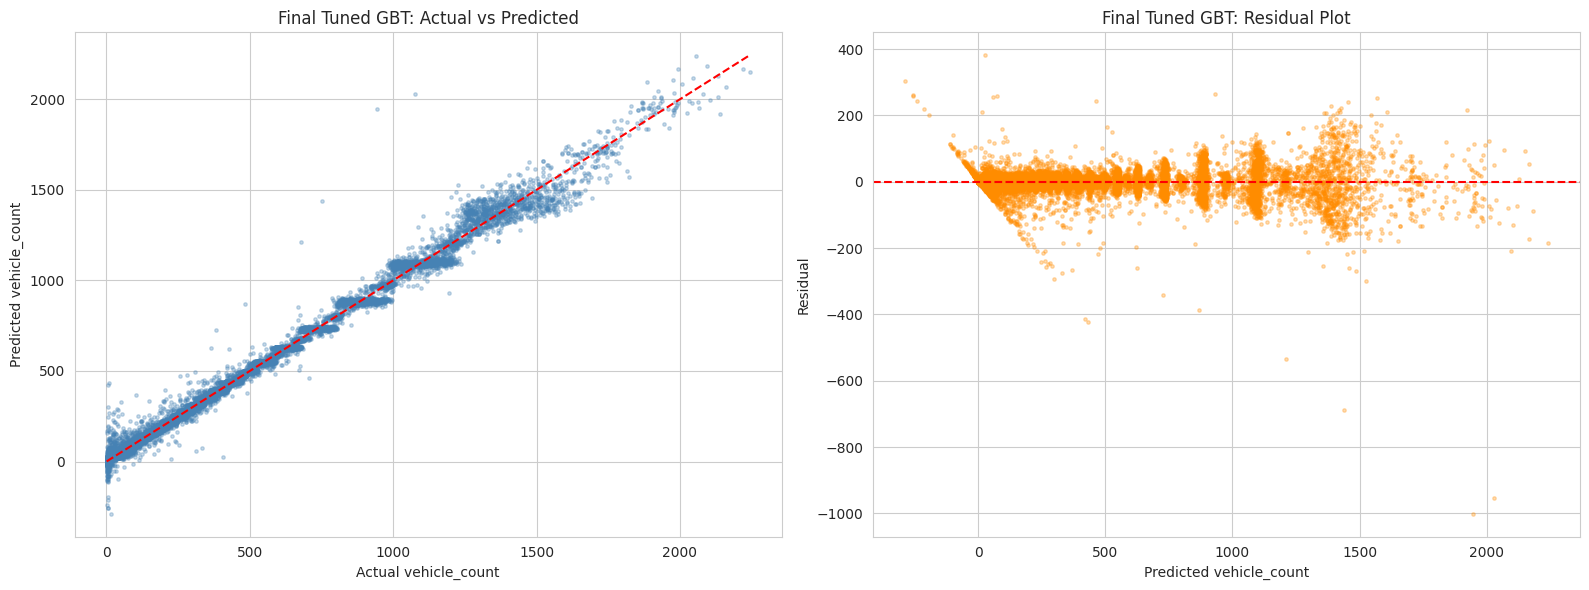

In [0]:
# Databricks notebook source
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sample_pd = (
    final_predictions
    .select("vehicle_count", "prediction")
    .sample(False, 0.02, seed=42)
    .toPandas()
)

sample_pd["residual"] = sample_pd["vehicle_count"] - sample_pd["prediction"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(sample_pd["vehicle_count"], sample_pd["prediction"], alpha=0.3, s=6, color="steelblue")
axes[0].plot([sample_pd["vehicle_count"].min(), sample_pd["vehicle_count"].max()],
             [sample_pd["vehicle_count"].min(), sample_pd["vehicle_count"].max()],
             color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Final Tuned GBT: Actual vs Predicted")
axes[0].set_xlabel("Actual vehicle_count")
axes[0].set_ylabel("Predicted vehicle_count")

axes[1].scatter(sample_pd["prediction"], sample_pd["residual"], alpha=0.3, s=6, color="darkorange")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Final Tuned GBT: Residual Plot")
axes[1].set_xlabel("Predicted vehicle_count")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

## Feature Importance and Model Explanation

Gradient Boosted Tree provides feature importance scores that indicate which variables contribute most to prediction accuracy.

 The importance ranking gives a clear explanation of the main drivers of traffic volume prediction.

feature,importance
avg_gap,0.5993391691963535
avg_headway,0.148562422229516
hour,0.13652448168610398
max_length,0.057843143575564644
avg_length,0.017983405361022508
length_std,0.008974172908062818
cosit,0.00884280219533207
avg_speed,0.004633282761494116
min_speed,0.0033644938021499377
lane,0.003247986705857059


/home/spark-e6a80248-fcf5-4cfb-8116-39/.ipykernel/1994/command-4548922033943324-3206111696:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(10), x="importance", y="feature", palette="viridis")


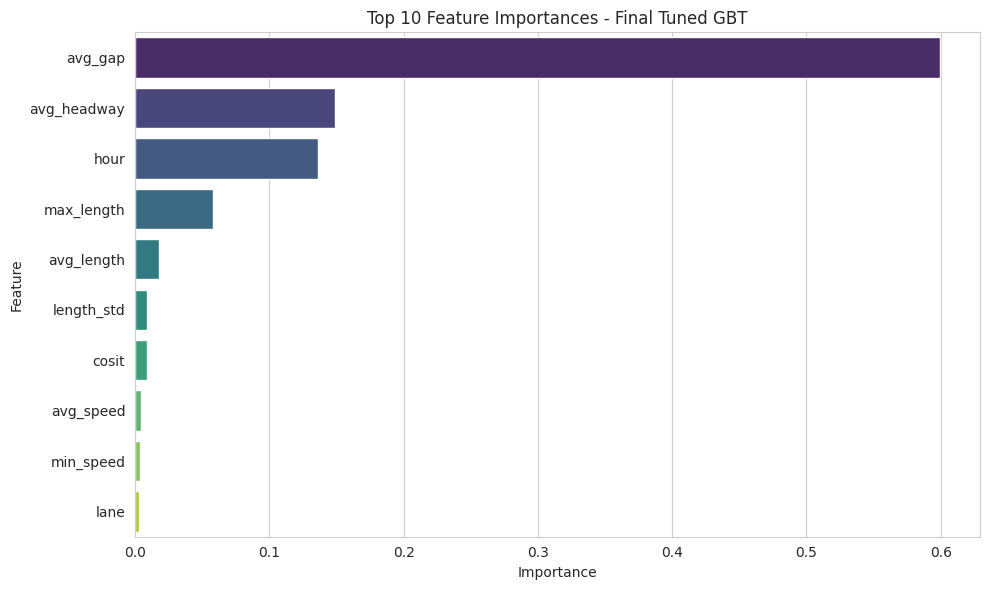

In [0]:
# Databricks notebook source
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importance = final_gbt_model.featureImportances.toArray()

importance_df = pd.DataFrame({
    "feature": final_features,
    "importance": importance
}).sort_values("importance", ascending=False)

display(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x="importance", y="feature", palette="viridis")
plt.title("Top 10 Feature Importances - Final Tuned GBT")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Interpretation of Feature Importance

The strongest predictors are gap, headway, and hour-related features.

This is reasonable because traffic flow depends heavily on spacing between vehicles and time patterns across the day.


##  Final Model Visualisations

The tuned Gradient Boosted Tree model is evaluated using multiple visualisations.

These plots assess:
- prediction accuracy,
- residual behaviour,
- error distribution,
- monthly stability,
- and comparison against baseline models.

In [0]:

from pyspark.sql.functions import col, abs as spark_abs, avg
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Add residuals and absolute errors
pred_vis = (
    final_predictions
    .withColumn("residual", col("vehicle_count") - col("prediction"))
    .withColumn("abs_error", spark_abs(col("vehicle_count") - col("prediction")))
)

# Sample for plotting
sample_pd = (
    pred_vis
    .select("vehicle_count", "prediction", "residual", "abs_error")
    .sample(False, 0.02, seed=42)
    .toPandas()
)

print("Plot sample size:", len(sample_pd))
sample_pd.head()

Plot sample size: 31099


,vehicle_count,prediction,residual,abs_error
0,68,79.565110,-11.565110,11.565110
1,1373,1413.845587,-40.845587,40.845587
2,1078,1110.728028,-32.728028,32.728028
3,6,298.622963,-292.622963,292.622963
4,2,-0.213212,2.213212,2.213212


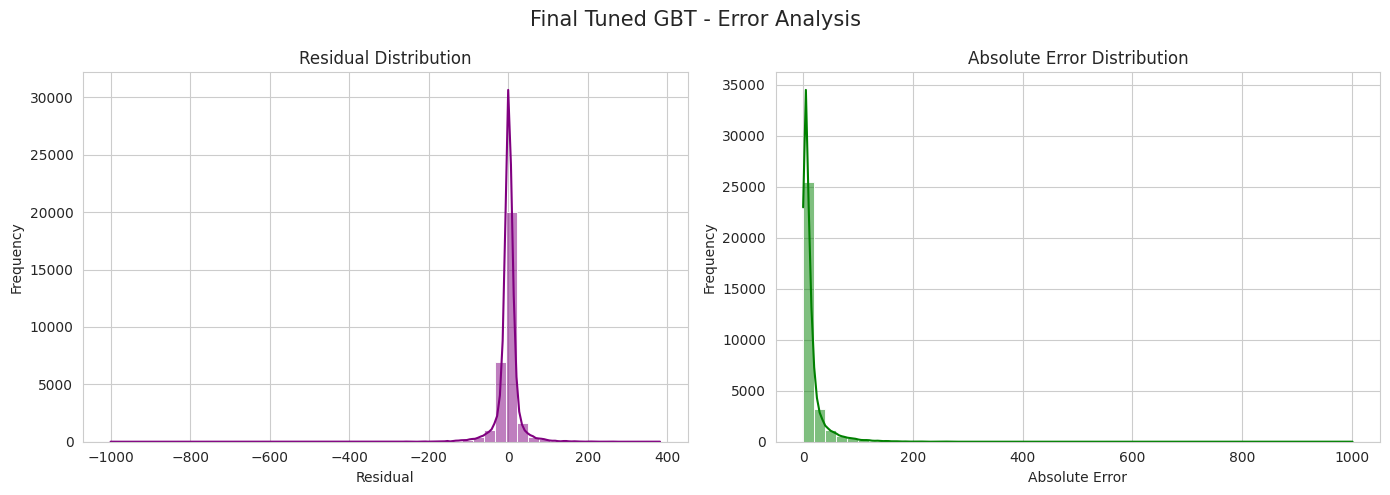

In [0]:
# Databricks notebook source
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Residual Distribution
sns.histplot(sample_pd["residual"], bins=50, kde=True, color="purple", ax=axes[0])
axes[0].set_title("Residual Distribution")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Frequency")

# 2. Absolute Error Distribution
sns.histplot(sample_pd["abs_error"], bins=50, kde=True, color="green", ax=axes[1])
axes[1].set_title("Absolute Error Distribution")
axes[1].set_xlabel("Absolute Error")
axes[1].set_ylabel("Frequency")

plt.suptitle("Final Tuned GBT - Error Analysis", fontsize=15)
plt.tight_layout()
plt.show()

 %md
  Error Analysis Interpretation

 The residual distribution is strongly concentrated around zero, which indicates that the final tuned GBT model is making accurate predictions for most observations.

 The absolute error distribution is right-skewed, showing that while most predictions are close to the true value, a smaller number of cases still produce larger errors.

 This pattern is expected in real-world traffic data, where unusual congestion, rapid speed changes, or local road effects can create harder-to-predict instances.

### Model Overview

It summarises the final predictive model, compares it against the baseline models, and presents the most important evaluation visuals.

- how well the model predicts traffic volume overall
- how the final model compares with the baselines
- whether the residuals are acceptable
- which features contribute most to the predictions

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, abs as spark_abs, avg

comparison_results = pd.DataFrame([
    ["Linear Regression", 231.8707, 166.7146, 0.5740],
    ["Generalised Linear Regression", 150.1206, 85.1184, 0.8214],
    ["Decision Tree", 47.0032, 19.5844, 0.9825],
    ["Random Forest", 43.8486, 19.8082, 0.9848],
    ["Baseline GBT", 30.6304, 15.5446, 0.9926],
    ["Final Tuned GBT", 28.49, 14.5085 , 0.9936]  
], columns=["Model", "RMSE", "MAE", "R2"])

In [0]:
final_summary = comparison_results.copy()
final_summary = final_summary.sort_values("R2", ascending=False).reset_index(drop=True)
display(spark.createDataFrame(final_summary))

Model,RMSE,MAE,R2
Final Tuned GBT,28.49,14.5085,0.9936
Baseline GBT,30.6304,15.5446,0.9926
Random Forest,43.8486,19.8082,0.9848
Decision Tree,47.0032,19.5844,0.9825
Generalised Linear Regression,150.1206,85.1184,0.8214
Linear Regression,231.8707,166.7146,0.574


/home/spark-e6a80248-fcf5-4cfb-8116-39/.ipykernel/1994/command-4548922033943333-2734676386:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_summary, x="RMSE", y="Model", palette="Blues_r")


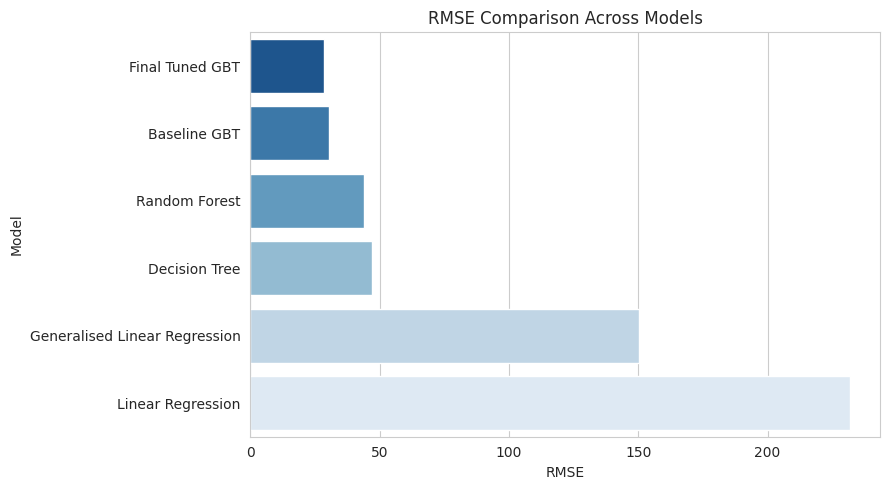

In [0]:
plt.figure(figsize=(9,5))
sns.barplot(data=final_summary, x="RMSE", y="Model", palette="Blues_r")
plt.title("RMSE Comparison Across Models")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

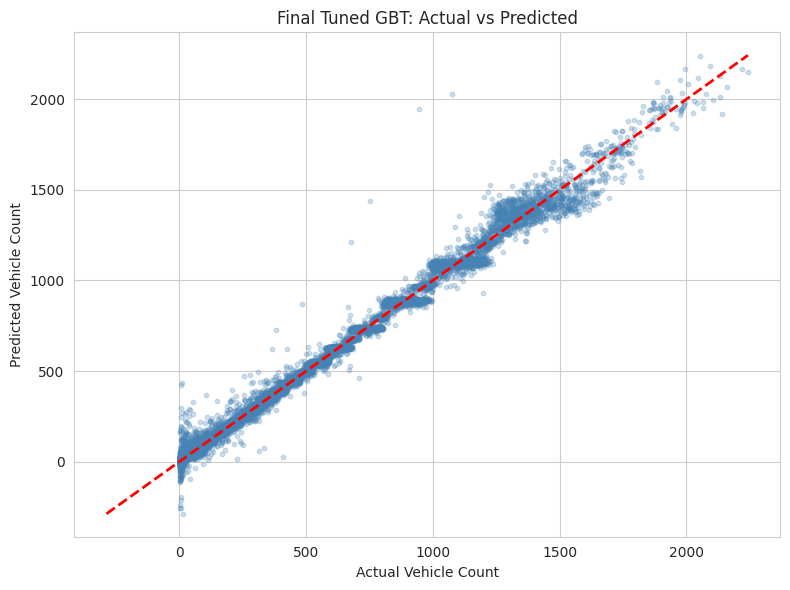

In [0]:
pred_sample = final_predictions.select("vehicle_count", "prediction").sample(False, 0.02, seed=42).toPandas()

plt.figure(figsize=(8,6))
plt.scatter(pred_sample["vehicle_count"], pred_sample["prediction"], alpha=0.25, s=10, color="steelblue")
mn = min(pred_sample["vehicle_count"].min(), pred_sample["prediction"].min())
mx = max(pred_sample["vehicle_count"].max(), pred_sample["prediction"].max())
plt.plot([mn, mx], [mn, mx], "r--", linewidth=2)
plt.title("Final Tuned GBT: Actual vs Predicted")
plt.xlabel("Actual Vehicle Count")
plt.ylabel("Predicted Vehicle Count")
plt.tight_layout()
plt.show()

### Actual vs Predicted Interpretation

The scatter plot shows a strong alignment between actual and predicted traffic volumes.  
Most points lie close to the 45-degree reference line, which indicates strong predictive accuracy.  
The model performs particularly well across the main traffic range, with only a small number of large-error outliers.  

This confirms that the tuned Gradient Boosted Tree model captures the non-linear traffic patterns in the data effectively.

The most influential predictors are avggap, avgheadway, and congestionindexindex, showing that spacing between vehicles and congestion state are the strongest drivers of traffic volume.  
Hour also contributes meaningfully, confirming clear time-of-day effects.  
The remaining features contribute smaller but still useful signal, helping the model refine predictions across locations and traffic conditions.

/home/spark-e6a80248-fcf5-4cfb-8116-39/.ipykernel/1994/command-4548922033943339-3200773563:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="RMSE", y="Model", ax=axes[0], palette="Blues_r")
/home/spark-e6a80248-fcf5-4cfb-8116-39/.ipykernel/1994/command-4548922033943339-3200773563:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="MAE", y="Model", ax=axes[1], palette="Oranges_r")
/home/spark-e6a80248-fcf5-4cfb-8116-39/.ipykernel/1994/command-4548922033943339-3200773563:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns

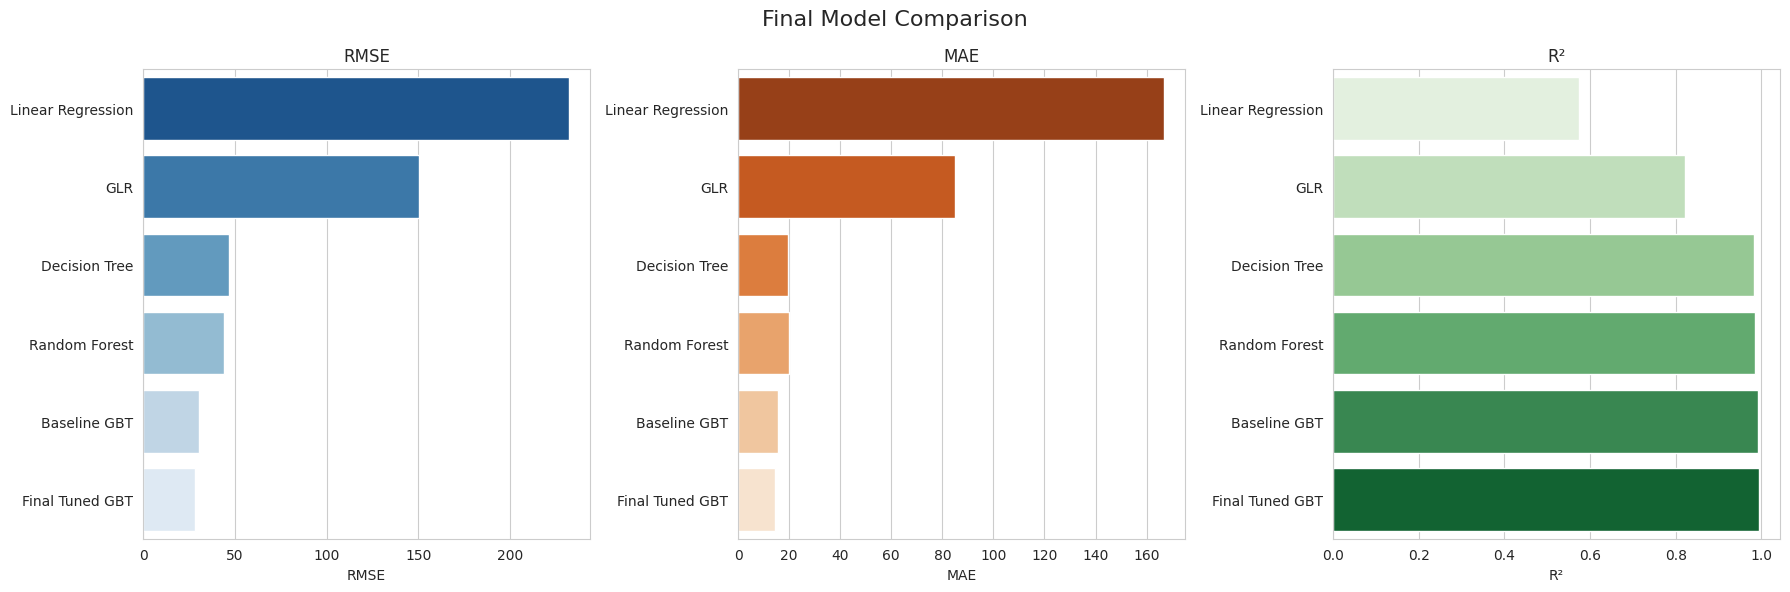

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "GLR",
        "Decision Tree",
        "Random Forest",
        "Baseline GBT",
        "Final Tuned GBT"
    ],
    "RMSE": [231.8707, 150.1206, 47.0032, 43.8486, 30.6304, 28.49],
    "MAE":  [166.7146, 85.1184, 19.5844, 19.8082, 15.5446, 14.5085],
    "R2":   [0.5740, 0.8214, 0.9825, 0.9848, 0.9926, 0.9936]
})

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(data=results, x="RMSE", y="Model", ax=axes[0], palette="Blues_r")
axes[0].set_title("RMSE")
axes[0].set_xlabel("RMSE")
axes[0].set_ylabel("")

sns.barplot(data=results, x="MAE", y="Model", ax=axes[1], palette="Oranges_r")
axes[1].set_title("MAE")
axes[1].set_xlabel("MAE")
axes[1].set_ylabel("")

sns.barplot(data=results, x="R2", y="Model", ax=axes[2], palette="Greens")
axes[2].set_title("R²")
axes[2].set_xlabel("R²")
axes[2].set_ylabel("")

plt.suptitle("Final Model Comparison", fontsize=16)
plt.tight_layout()
plt.show()

###Conclusion
This project built a scalable Apache Spark ML pipeline to predict hourly traffic volume (vehiclecount) on Irish roads using cleaned, engineered, and selected features, with a full workflow of preprocessing, exploratory analysis, feature selection, baseline modelling, and hyperparameter tuning. It used a temporal train/test split from January to September for training and October to December for testing, so the evaluation reflected realistic future forecasting and avoided leakage; the final feature set contained 19 variables after removing leakage-prone and highly correlated columns, and the best model was a tuned Gradient Boosted Tree that improved on the strongest baseline from RMSE 30.6304, MAE 15.5446, and R² 0.9926 to RMSE 28.49 with maxDepth 10, maxIter 50, and stepSize 0.1.

A comparison bar chart of RMSE, MAE, and R² across all models because it gives the clearest final justification for selecting the tuned Gradient Boosted Tree. Model comparison shows that tree-based methods outperform linear baselines, and the tuned Gradient Boosted Tree achieves the best overall performance.”

This project successfully developed a robust Spark-based traffic prediction system using preprocessing, feature selection, baseline comparison, and hyperparameter tuning. The final tuned Gradient Boosted Tree model achieved the best performance and produced highly accurate predictions on the held-out test set, confirming that it is the most suitable model for this dataset. Overall, the project meets its objectives and shows that careful data preparation, temporal evaluation, and ensemble modelling are essential for accurate traffic volume prediction.